# Plots capitulo 5

In [30]:
import numpy as np
import polars as pl
import pandas as pd
from drawarrow import ax_arrow
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


___

## Funciones

In [31]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "mathtext.fontset": "dejavusans",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{sfmath} \usepackage{textcomp}",
    "axes.edgecolor": "#666666",
    "axes.labelcolor": "#666666",
    "axes.titlecolor": "#666666",
    "xtick.color": "#666666",
    "ytick.color": "#666666",
    "text.color": "#666666",
    "axes.facecolor": 'none'
})

In [32]:
def plot_microhetero(df, save_path=None, factor=1):
    """
    Figura de heterogeneidad microestructural: 3 paneles
    (a) Composición mineralógica - barras apiladas
    (b) Porosidad digital - barras simples  
    (c) Factor de forma T_G - puntos
    """
    sample_colors = {
        "L187": "#2a78d6",
        "L35":  "#eb6834",
        "L36":  "#1baf7a",
        "L37":  "#eda100",
    }
    mineral_colors = {
        "albita":        "#4a90c4",
        "cristobalita":  "#e8a838",
        "enstatita":     "#6ab187",
        "sanidino":      "#c47a5a",
    }

    muestras = df["muestra"].tolist()
    x = np.arange(len(muestras))
    width = 0.5

    fig, axes = plt.subplots(1, 3, figsize=(13*factor, 4.5*factor), dpi=300)
    fig.subplots_adjust(wspace=0.38)

    # --- (a) Composición mineralógica ---
    ax = axes[0]
    minerales = ["albita", "cristobalita", "enstatita", "sanidino"]
    mineral_labels = {
        "albita":        "Albita",
        "cristobalita":  "Cristobalita",
        "enstatita":     "Enstatita",
        "sanidino":      "Sanidino",
    }
    bottom = np.zeros(len(muestras))

    for mineral in minerales:
        vals = df[mineral].to_numpy()
        ax.bar(x, vals, width, bottom=bottom, color=mineral_colors[mineral], label=mineral_labels[mineral])
        for i, (v, b) in enumerate(zip(vals, bottom)):
            if v > 3:
                ax.text(x[i], b + v / 2, f"{v:.0f}", ha="center", va="center",  fontsize=7.5, color="white")
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"Contenido mineral (\%)", fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.legend(fontsize=8, ncols=2, frameon=False, loc="upper right", bbox_to_anchor=(1, 1.1))
    ax.text(-0.15, 1.06, "(a)", transform=ax.transAxes, fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    
    # --- (b) Porosidad — dumbbell vertical ---
    ax = axes[1]
    poros_exp = df["porosidad_exp"].to_numpy()   # ajusta el nombre de columna
    poros_dig = df["porosidad"].to_numpy()
    colors_list = [sample_colors[m] for m in muestras]
    
    for i, (pexp, pdig, c) in enumerate(zip(poros_exp, poros_dig, colors_list)):
        # línea vertical conectando ambos puntos
        ax.plot([i, i], [pexp, pdig], color=c, lw=1.5, zorder=2)
        # punto digital — círculo hueco
        ax.scatter(i, pdig, color=c, s=40, zorder=3, edgecolors=c, linewidths=1., facecolors="white", marker="o", label="Digital" if i == 0 else "")
        # punto experimental — círculo relleno
        ax.scatter(i, pexp, color=c, s=40, zorder=3, linewidths=0.5, edgecolors=c, marker="o", label="Experimental" if i == 0 else "")
        # anotar valores
        ax.text(i + 0.15, pexp+0.15, f"{pexp:.2f}", va="center", fontsize=7.5, color=c)
        ax.text(i + 0.15, pdig-0.15, f"{pdig:.2f}", va="center", fontsize=7.5, color=c)

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"Porosidad (\%)", fontsize=10)
    ax.set_ylim(0, 11)
    ax.set_xlim(-0.4, len(muestras) - 0.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.15, 1.06, "(b)", transform=ax.transAxes, fontsize=12, fontweight="bold")

    # leyenda manual
    handles = [
        Line2D([0],[0], marker="o", color="gray", lw=0,markerfacecolor="gray", markersize=7, label="Experimental"),
        Line2D([0],[0], marker="o", color="gray", lw=0,markerfacecolor="white", markeredgecolor="gray", markersize=7, label="Digital"),
    ]
    ax.legend(handles=handles, fontsize=8, frameon=False, loc="upper left", bbox_to_anchor=(0, 1.01))

    # --- (c) Factor de forma T_G ---
    ax = axes[2]
    tg = df["TG"].to_numpy()

    ax.axhline(0, color="#c3c2b7", lw=1, ls="--", zorder=1)
    ax.axhspan( 0,  1, alpha=0.05, color="#eb6834")
    ax.axhspan(-1,  0, alpha=0.05, color="#2a78d6")
    ax.text(3.15,  0.98, "oblato",  fontsize=8, color="#666666", va="top",    ha="right", style="italic")
    ax.text(3.12, -0.98, "prolato", fontsize=8, color="#666666", va="bottom", ha="right", style="italic")

    for i, (m, v) in enumerate(zip(muestras, tg)):
        ax.scatter(i, v, color=sample_colors[m], s=90, zorder=3, edgecolors="white", linewidths=0.8)
        offset = 0.09 if v >= 0 else -0.09
        va = "bottom" if v >= 0 else "top"
        ax.text(i, v + offset, f"{v:.2f}", ha="center", va=va, fontsize=8, color=sample_colors[m])

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"Factor de forma $T_G$ de los poros", fontsize=10)
    ax.set_ylim(-1, 1)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1])
    ax.text(-0.15, 1.06, "(c)", transform=ax.transAxes, fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

In [33]:
def plot_phiDiffs(df2, save_path=None, factor=1):
    fig, ax = plt.subplots(figsize=(15 * factor, 8 * factor), dpi=300)

    plot_cfg = dict(linewidth=2.5, zorder=1, alpha=0.85)
    scatter_cfg = dict(s=40, color='white', edgecolors='k', linewidth=1., zorder=3, alpha=0.85)
    colors = {'Ferreira': "#1baf7a", 'Vidal': "#eb6834", 'Buono': "#eda100", 'Este estudio': "#2a78d6"}
    symbols = {'Lab': 'o'}
    ct_cfg = {'LR(64-48μm)': '^', 'MR(28-6μm)': 's', 'HR(4-2.25μm)': 'd'}

    def plot_data(ax, df):
        for y, row in enumerate(df.iter_rows(named=True), start=1):
            lab = row['Lab']
            color = colors[row['Estudio']]
            ax.scatter(lab, y, marker=symbols['Lab'], **scatter_cfg)
            for col, marker in ct_cfg.items():
                if (value := row[col]) is not None:
                    ax.plot([lab, value], [y, y], color=color, solid_capstyle='round', **plot_cfg)
                    ax.scatter(value, y, marker=marker, **scatter_cfg)

    # --- Grafico principal ---
    plot_data(ax, df2)

    ax.text(x=44.2, y=27.8, s=r'--14\%', size=11, ha="right")
    ax_arrow(tail_position=(44.3, 28.3), head_position=(48, 25.8), ax=ax, color="#666666", width=0.95, head_width=2, head_length=5, radius=-0.2)

    ax.text(x=70, y=35, s=r'+23\%', size=11, ha="right")
    ax_arrow(tail_position=(66.5, 35.2), head_position=(62, 37.95), ax=ax, color="#666666", width=0.95, head_width=2, head_length=5, radius=-0.2)

    ax.set_xlabel(r'Porosidad (\%)', fontsize=11)
    ax.set_title('Comparación de valores de porosidad experimental y por microCT reportados en la literatura', fontsize=13, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.2, axis='x')
    ax.set_axisbelow(True)
    ax.set_xlim(0, 75)
    ax.set_ylim(0.5, 40)
    ax.yaxis.set_visible(False)

    legend_elements = [
        Line2D([0], [0], color='w', marker='o', markerfacecolor='white', markeredgecolor='k', markersize=8, label='Laboratorio'),
        Line2D([0], [0], color='w', marker='^', markerfacecolor='white', markeredgecolor='k', markersize=8, label=r'Baja resolución: 48-64 \textmu m'),
        Line2D([0], [0], color='w', marker='s', markerfacecolor='white', markeredgecolor='k', markersize=8, label=r'Media resolución: 6-28 \textmu m'),
        Line2D([0], [0], color='w', marker='d', markerfacecolor='white', markeredgecolor='k', markersize=8, label=r'Alta resolución: 2.25-4 \textmu m'),
        Line2D([0], [0], color=colors['Este estudio'], linewidth=4, label='Este estudio'),
        Line2D([0], [0], color=colors['Vidal'], linewidth=4, label='Vidal et al. (2024)'),
        Line2D([0], [0], color=colors['Ferreira'], linewidth=4, label='Esteves-Ferreira et al. (2023)'),
        Line2D([0], [0], color=colors['Buono'], linewidth=4, label='Buono et al. (2023)'),
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9, framealpha=1, ncol=1, facecolor='white')
    ax.spines[['top', 'right']].set_visible(False)

    axins = inset_axes(ax, width="35%", height="30%", bbox_to_anchor=(0.30, 0.08, 1, 1), bbox_transform=ax.transAxes, loc='lower left')
    plot_data(axins, df2)
    axins.text(x=1.9, y=1.2, s=r'\textbf{L187}', size=9, ha="center")
    axins.text(x=4.5, y=2.2, s=r'\textbf{L35}', size=9, ha="center")
    axins.text(x=2.9, y=3.2, s=r'\textbf{L36}', size=9, ha="center")
    axins.text(x=9, y=4.2, s=r'\textbf{L37}', size=9, ha="center")

    axins.text(x=10, y=2.85, s=r'-- 4.5\%', size=9, ha="right")
    ax_arrow(tail_position=(9., 3.2), head_position=(8.5, 3.9), ax=axins, color="#666666", width=0.6, head_width=1.3, head_length=3, radius=-0.2)

    axins.set_xlim(0.9, 11.1)
    axins.set_ylim(0.5, 4.5)
    axins.grid(True, alpha=0.2, axis='x')
    axins.set_axisbelow(True)
    axins.yaxis.set_visible(False)
    axins.tick_params(labelsize=8)
    axins.set_facecolor('white')

    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", lw=0.5, ls="--")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

In [34]:
def plot_cte_drx(df, save_path=None, factor=1):
    mineral_colors = {
        "albita":        "#2a5a8a",
        "cristobalita":  "#e8a838",
        "enstatita":     "#6ab187",
        "sanidino":      "#c47a5a",
    }
    fluid_styles = {
        "aire":  {"color": "#444441", "ls": (0, (1, 1)),  "lw": 1.4, "label": "Aire"},
        "vapor": {"color": "#444441", "ls": (0, (5, 10)), "lw": 1.4, "label": "Vapor"},
        "agua":  {"color": "#2a78d6", "ls": "-",  "lw": 1.8, "label": "Agua"},
    }

    muestras = df["muestra"].tolist()
    x = np.arange(len(muestras))
    width = 0.35
    k_min, k_max = 2.2, 4.

    def scale_to_k(val, total=100):
        return k_min + (val / total) * (k_max - k_min)

    fig, ax = plt.subplots(figsize=(8*factor, 5*factor), dpi=300)

    # drx
    minerales = ["albita", "cristobalita", "enstatita", "sanidino"]
    bottom_pct = np.zeros(len(muestras))

    for mineral in minerales:
        vals = df[mineral].to_numpy()
        bottom_k = np.array([scale_to_k(b) for b in bottom_pct])
        heights_k = np.array([scale_to_k(v) - k_min for v in vals])

        ax.bar(x, heights_k, width * 2.2, bottom=bottom_k, alpha=0.2, zorder=1)

        for i, (v, bk) in enumerate(zip(vals, bottom_k)):
            if v > 3:
                ax.text(x[i] + (width * 2.2 / 2) - 0.02, bk + 0.01, rf"{v:.0f}\%", ha="right", va="bottom", fontsize=6.5, color=mineral_colors[mineral])
        bottom_pct += vals

    # keff
    for fluido, style in fluid_styles.items():
        kvals = df[f"k_{fluido}"].to_numpy()
        ax.plot(x, kvals, lw=style["lw"], ls=style["ls"], color=style["color"], label=style["label"], zorder=3)
        for i, v in enumerate(kvals):
            ax.scatter(i, v, color=style["color"], s=55, zorder=4, edgecolors="white", linewidths=0.8)

    # labels
    for i, v in enumerate(df["k_agua"].to_numpy()):
        ax.text(x[i]-0.1, v + 0.04, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#2a78d6")
    # for i, v in enumerate(df["k_aire"].to_numpy()):
    #         ax.text(x[i]+0.14, v - 0.04, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#444441")
    for i, v in enumerate(df["k_vapor"].to_numpy()):
                ax.text(x[i]+0.14, v - 0.07, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#444441")

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlim(-0.4, len(muestras) - 0.4)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"$k_\mathrm{eff}$ (W/mK)", fontsize=10)
    ax.set_ylim(k_min, k_max)
    ax.spines[["top", "right"]].set_visible(False)

    fluid_handles = [
        Line2D([0],[0], color=s["color"], lw=s["lw"], ls=s["ls"], label=s["label"])
        for s in fluid_styles.values()
    ]
    mineral_handles = [
        mpatches.Patch(color=mineral_colors[m], alpha=0.5, label=m.capitalize())
        for m in minerales
    ]
    ax.legend(handles=fluid_handles + mineral_handles, fontsize=8, frameon=True, framealpha=0.9, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

In [35]:
def plot_cte_fluid_ani(df, save_path=None, factor=1):
    """
    Panel (a) — Δk (%) por muestra y eje: efecto del fluido saturante
    Panel (b) — Anisotropía (%) por muestra y fluido
    """
    sample_colors = {
        "L187": "#2a78d6",
        "L35":  "#eb6834",
        "L36":  "#1baf7a",
        "L37":  "#eda100",
    }
    fluid_styles = {
        "aire":  {"color": "#444441", "marker": "o", "ls": ":",  "label": "Aire"},
        "vapor": {"color": "#888780", "marker": "s", "ls": (0,(5,10)), "label": "Vapor"},
        "agua":  {"color": "#2a78d6", "marker": "^", "ls": "-",  "label": "Agua"},
    }

    muestras = df["muestra"].tolist()
    x = np.arange(len(muestras))
    dk = {
        "xx": [1.86, 1.06, 0.36, 0.19],
        "yy": [1.49, 1.02, 0.36, 0.19],
        "zz": [1.78, 1.02, 0.29, 0.35],
    }
    aniso = {
        "aire":  [0.50, 0.26, 0.23, 0.28],
        "vapor": [0.48, 0.25, 0.23, 0.27],
        "agua":  [0.18, 0.22, 0.13, 0.13],
    }

    fig, axes = plt.subplots(1, 2, figsize=(10*factor, 4.5*factor), dpi=300)
    fig.subplots_adjust(wspace=0.15)

    # -------------------------------------------------------
    # Panel (a) — Δk por eje
    # -------------------------------------------------------
    ax = axes[0]
    eje_colors = {"xx": "#4a90c4", "yy": "#e8a838", "zz": "#6ab187"}
    eje_markers = {"xx": "o", "yy": "^", "zz": "s"}
    width = 0.22
    offsets = {"xx": -width, "yy": 0, "zz": width}

    for eje, vals in dk.items():
        bars = ax.bar(x + offsets[eje], vals, width, color=eje_colors[eje], alpha=0.85, label=f"$k_{{{eje}}}$")
        for i, v in enumerate(vals):
            ax.text(x[i] + offsets[eje], v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color=eje_colors[eje], rotation=45, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"$\Delta k$ (\%)", fontsize=10)
    ax.set_ylim(0, 2.4)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.12, 1.06, "(a)", transform=ax.transAxes, fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, frameon=False, loc="upper right", title=r"$\Delta k = (k_\mathrm{agua}-k_\mathrm{aire})/k_\mathrm{aire}\times100$", title_fontsize=9)

    # -------------------------------------------------------
    # Panel (b) — Anisotropía por fluido
    # -------------------------------------------------------
    ax = axes[1]

    for fluido, style in fluid_styles.items():
        vals = aniso[fluido]
        ax.plot(x, vals, color=style["color"], ls=style["ls"], lw=1.4, zorder=2, label=style["label"])
        ax.scatter(x, vals, color=style["color"], marker=style["marker"], s=60, zorder=3, edgecolors="white", linewidths=0.8)
        if fluido == "agua":
            for i, v in enumerate(vals):
                ax.text(x[i], v - 0.015, f"{v:.2f}", ha="center", va="top", fontsize=7.5, color=style["color"])
        if fluido == "aire":
                    for i, v in enumerate(vals):
                        ax.text(x[i]+0.05, v + 0.03, f"{v:.2f}", ha="center", va="top", fontsize=7.5, color=style["color"])

    # línea de referencia 0.5%
    ax.axhline(0.5, color="#c3c2b7", lw=1, ls="--", zorder=1)
    ax.text(3.05, 0.51, "0.5\\%", fontsize=7.5, color="#898781", va="bottom")

    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=11, fontweight="bold")
    ax.set_ylabel(r"Anisotropía (\%)", fontsize=10)
    ax.set_ylim(0, 0.65)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.12, 1.06, "(b)", transform=ax.transAxes, fontsize=12, fontweight="bold")
    handles = [
        Line2D([0],[0], color=s["color"], lw=1.4,
               ls=s["ls"], marker=s["marker"],
               markerfacecolor=s["color"],
               markeredgecolor="white", markersize=6,
               label=s["label"])
        for s in fluid_styles.values()
    ]
    ax.legend(handles=handles, fontsize=8, frameon=False, loc="upper right")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

In [36]:
def plot_vels(df, save_path=None,factor=1):
    """
    Panel (a) — Vp vs porosidad
    Panel (b) — Vs1 y Vs2 vs porosidad
    Panel (c) — Desdoblamiento ΔVs = Vs1 - Vs2 por muestra
    """
    sample_colors = {
        "L187": "#2a78d6",
        "L35":  "#eb6834",
        "L36":  "#1baf7a",
        "L37":  "#eda100",
    }
    fabrica = {
        "L187": "prolata\n(lin. Y)",
        "L35":  "oblata\n(fol. XY)",
        "L36":  "prolata\n(lin. Z)",
        "L37":  "oblata\n(fol. XY)",
    }

    muestras  = df["muestra"].tolist()
    porosidad = df["porosidad_exp"].to_numpy()
    vp        = df["vp"].to_numpy()
    vs1       = df["vs1"].to_numpy()
    vs2       = df["vs2"].to_numpy()
    dvs       = vs1 - vs2  # desdoblamiento
    xs        = np.linspace(porosidad.min() - 0.3, porosidad.max() + 0.3, 100)
    offsets_a = {"L187": (-0.25, 120), "L35": (0.1, -220), "L36": (0.3, 80), "L37": (0.1, 120)}
    colors_list = [sample_colors[m] for m in muestras]

    fig, axes = plt.subplots(1, 3, figsize=(13*factor, 4.5*factor), dpi=300)
    fig.subplots_adjust(wspace=0.35)

    # --- (a) Vp vs porosidad ---
    ax = axes[0]
    m, b = np.polyfit(porosidad, vp, 1)
    ax.plot(xs, m*xs + b, color="#c3c2b7", lw=1, ls="--", zorder=1)
    for i, (mn, c) in enumerate(zip(muestras, colors_list)):
        ax.scatter(porosidad[i], vp[i], color=c, s=90, zorder=3, edgecolors="white", linewidths=0.8)
        dx, dy = offsets_a[mn]
        ax.text(porosidad[i]+dx, vp[i]+dy, mn, fontsize=8, color=c)
    ax.set_xlabel(r"Porosidad (\%)", fontsize=10)
    ax.set_ylabel(r"$V_P$ (m/s)", fontsize=10)
    ax.set_xlim(0, 12)
    ax.set_ylim(2000, 5500)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.15, 1.06, "(a)", transform=ax.transAxes, fontsize=12, fontweight="bold")

    # --- (b) Vs1 y Vs2 vs porosidad ---
    ax = axes[1]
    for vs, ls in [(vs1, "-"), (vs2, "--")]:
        mf, bf = np.polyfit(porosidad, vs, 1)
        ax.plot(xs, mf*xs + bf, color="#c3c2b7", lw=1, ls=ls, zorder=1)
    for i, (mn, c) in enumerate(zip(muestras, colors_list)):
        ax.scatter(porosidad[i], vs1[i], color=c, s=90, marker="o", zorder=3, edgecolors=c, linewidths=1.5)
        ax.scatter(porosidad[i], vs2[i], color=c, s=90, marker="o", zorder=3, edgecolors=c, linewidths=1.5, facecolors="white")
        ax.plot([porosidad[i], porosidad[i]], [vs2[i], vs1[i]], color=c, lw=1.2, alpha=0.5, zorder=2)
    handles = [Line2D([0],[0], marker="o", color="gray", lw=0, markerfacecolor="gray", markeredgecolor="gray", markersize=7, label=r"$V_{S1}$"),
               Line2D([0],[0], marker="o", color="gray", lw=0, markerfacecolor="white", markeredgecolor="gray", markersize=7, label=r"$V_{S2}$")]
    ax.legend(handles=handles, fontsize=8, frameon=False, loc="upper right")
    ax.set_xlabel(r"Porosidad (\%)", fontsize=10)
    ax.set_ylabel(r"$V_S$ (m/s)", fontsize=10)
    ax.set_xlim(0, 12)
    ax.set_ylim(1500, 3500)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.15, 1.06, "(b)", transform=ax.transAxes, fontsize=12, fontweight="bold")

    # --- (c) ΔVs por muestra ---
    ax = axes[2]
    x = np.arange(len(muestras))
    ax.bar(x, dvs, 0.5, color=colors_list, alpha=0.85)
    for i, v in enumerate(dvs):
        ax.text(x[i], v + (8 if v >= 0 else -8), f"{v:.0f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8, color=colors_list[i])
        ax.text(x[i], dvs.max()*1.4, fabrica[muestras[i]], ha="center", va="bottom", fontsize=6.5, color=colors_list[i], style="italic")
    ax.axhline(0, color="#c3c2b7", lw=0.8, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels(muestras)
    ax.set_xlabel("Muestra", fontsize=10)
    ax.set_ylabel(r"$\Delta V_S = V_{S1} - V_{S2}$ (m/s)", fontsize=10)
    ax.set_ylim(dvs.min()*1.1, dvs.max()*1.35)
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(-0.15, 1.06, "(c)", transform=ax.transAxes, fontsize=12, fontweight="bold")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

In [37]:
def plot_k_vs_v(df, save_path=None, factor=1):
    sample_colors = {"L187": "#2a78d6", "L35": "#eb6834", "L36": "#1baf7a", "L37": "#eda100"}
    vel_styles = {
        "vp":  {"marker": "o", "ls": "-",         "label": r"$V_P$"},
        "vs1": {"marker": "^", "ls": ":",         "label": r"$V_{S1}$"},
        "vs2": {"marker": "s", "ls": (0,(5,10)),   "label": r"$V_{S2}$"},
    }
    offsets = {"L187": (-0.04, 120), "L35": (0.01, 350), "L36": (0.01, -380), "L37": (0.03, 120)}

    muestras = df["muestra"].tolist()
    k = df["k_agua"].to_numpy()
    colors_list = [sample_colors[m] for m in muestras]

    fig, ax = plt.subplots(figsize=(8*factor, 5*factor), dpi=300)

    for vel, style in vel_styles.items():
        v = df[vel].to_numpy()
        # línea conectando las 4 muestras ordenadas por k
        idx = np.argsort(k)
        ax.plot(k[idx], v[idx], color="#c3c2b7", lw=1, ls=style["ls"], zorder=1)
        for i, (mn, c) in enumerate(zip(muestras, colors_list)):
            ax.scatter(k[i], v[i], color=c, marker=style["marker"], s=80, zorder=3, linewidths=0.8, alpha=0.7)

    # etiquetar muestras una sola vez (sobre Vp)
    vp = df["vp"].to_numpy()
    for i, (mn, c) in enumerate(zip(muestras, colors_list)):
        dx, dy = offsets[mn]
        ax.text(k[i]+dx, vp[i]+dy, mn, fontsize=8.5, color=c)

    # anotaciones de control
    ax.text(0.03, 0.97, r"$k$ controlada por mineralogía $\to$",
            transform=ax.transAxes, fontsize=8, color="#52514e",
            va="top", style="italic")
    ax.text(0.97, 0.03, r"$\gets$ $V_{P,S}$ controlada por porosidad",
            transform=ax.transAxes, fontsize=8, color="#52514e",
            va="bottom", ha="right", style="italic")

    handles = [Line2D([0],[0], color="#888780", lw=1.2, ls=style["ls"],
                      marker=style["marker"], markerfacecolor="#888780",
                      markeredgecolor="white", markersize=6, label=style["label"])
               for style in vel_styles.values()]
    ax.legend(handles=handles, fontsize=8, frameon=False, loc="upper right")

    ax.set_xlabel(r"$k_\mathrm{eff}$ (W/mK)", fontsize=10)
    ax.set_ylabel(r"$V_{P,S}$ (m/s)", fontsize=10)
    ax.set_xlim(2.4,4.)
    ax.set_ylim(1000,6000)
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Figura guardada en: {save_path}")
    plt.show()

## Lectura de datos

### df1 - resultados

In [38]:
df1 = pd.read_csv('datasets/ch5.csv')
df1['k_aire'] = (df1['kxx_aire'] + df1['kyy_aire'] + df1['kzz_aire']) / 3
df1['k_vapor'] = (df1['kxx_vapor'] + df1['kyy_vapor'] + df1['kzz_vapor']) / 3
df1['k_agua'] = (df1['kxx_agua'] + df1['kyy_agua'] + df1['kzz_agua']) / 3
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   muestra        4 non-null      object 
 1   vp             4 non-null      int64  
 2   vs1            4 non-null      int64  
 3   vs2            4 non-null      int64  
 4   kxx_aire       4 non-null      float64
 5   kyy_aire       4 non-null      float64
 6   kzz_aire       4 non-null      float64
 7   kxx_vapor      4 non-null      float64
 8   kyy_vapor      4 non-null      float64
 9   kzz_vapor      4 non-null      float64
 10  kxx_agua       4 non-null      float64
 11  kyy_agua       4 non-null      float64
 12  kzz_agua       4 non-null      float64
 13  albita         4 non-null      float64
 14  cristobalita   4 non-null      float64
 15  enstatita      4 non-null      float64
 16  sanidino       4 non-null      float64
 17  porosidad      4 non-null      float64
 18  porosidad_exp 

### df2 - comparación de porosidades

Datos de 3 estudios:
- Esteves Ferreira, M., Rodrigues Del Grande, M., Neumann Barros Ferreira, R. et al. Full scale, microscopically resolved tomographies of sandstone and carbonate rocks augmented by experimental porosity and permeability values. Sci Data 10, 368 (2023). https://doi.org/10.1038/s41597-023-02259-z 
- Vidal, A.D., Neta, A.P.M., de Castro Vargas Fernandes, J. et al. Multi-resolution X-ray micro-computed tomography images of carbonate rocks from brazilian pre-salt. Sci Data 11, 1361 (2024). https://doi.org/10.1038/s41597-024-04198-9
- Buono, G., Caliro, S., Macedonio, G. et al. Exploring microstructure and petrophysical properties of microporous volcanic rocks through 3D multiscale and super-resolution imaging. Sci Rep 13, 6651 (2023). https://doi.org/10.1038/s41598-023-33687-x

In [39]:
df2 = pl.read_csv('datasets/porosityComparison.csv')
df2 = df2.with_row_index('N', offset=1)
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df2.sort('Lab', descending=True))

shape: (39, 7)
┌─────┬──────────────┬──────────┬───────┬─────────────┬────────────┬──────────────┐
│ N   ┆ Estudio      ┆ Muestra  ┆ Lab   ┆ LR(64-48μm) ┆ MR(28-6μm) ┆ HR(4-2.25μm) │
│ --- ┆ ---          ┆ ---      ┆ ---   ┆ ---         ┆ ---        ┆ ---          │
│ u32 ┆ str          ┆ str      ┆ f64   ┆ f64         ┆ f64        ┆ f64          │
╞═════╪══════════════╪══════════╪═══════╪═════════════╪════════════╪══════════════╡
│ 25  ┆ Ferreira     ┆ 6A       ┆ 53.45 ┆ null        ┆ null       ┆ 39.18        │
│ 39  ┆ Buono        ┆ CI Tuff  ┆ 51.0  ┆ null        ┆ 74.0       ┆ 49.0         │
│ 36  ┆ Ferreira     ┆ EdB-1    ┆ 29.63 ┆ null        ┆ null       ┆ 18.45        │
│ 30  ┆ Ferreira     ┆ 20A      ┆ 28.48 ┆ null        ┆ null       ┆ 27.54        │
│ 26  ┆ Ferreira     ┆ 13A      ┆ 27.39 ┆ null        ┆ null       ┆ 17.23        │
│ 34  ┆ Ferreira     ┆ EdY      ┆ 25.96 ┆ null        ┆ null       ┆ 16.84        │
│ 29  ┆ Ferreira     ┆ 18A      ┆ 25.0  ┆ null        ┆ null 

___

## Figuras

### 5-1

Figura guardada en: plots/ch5-fig1.png


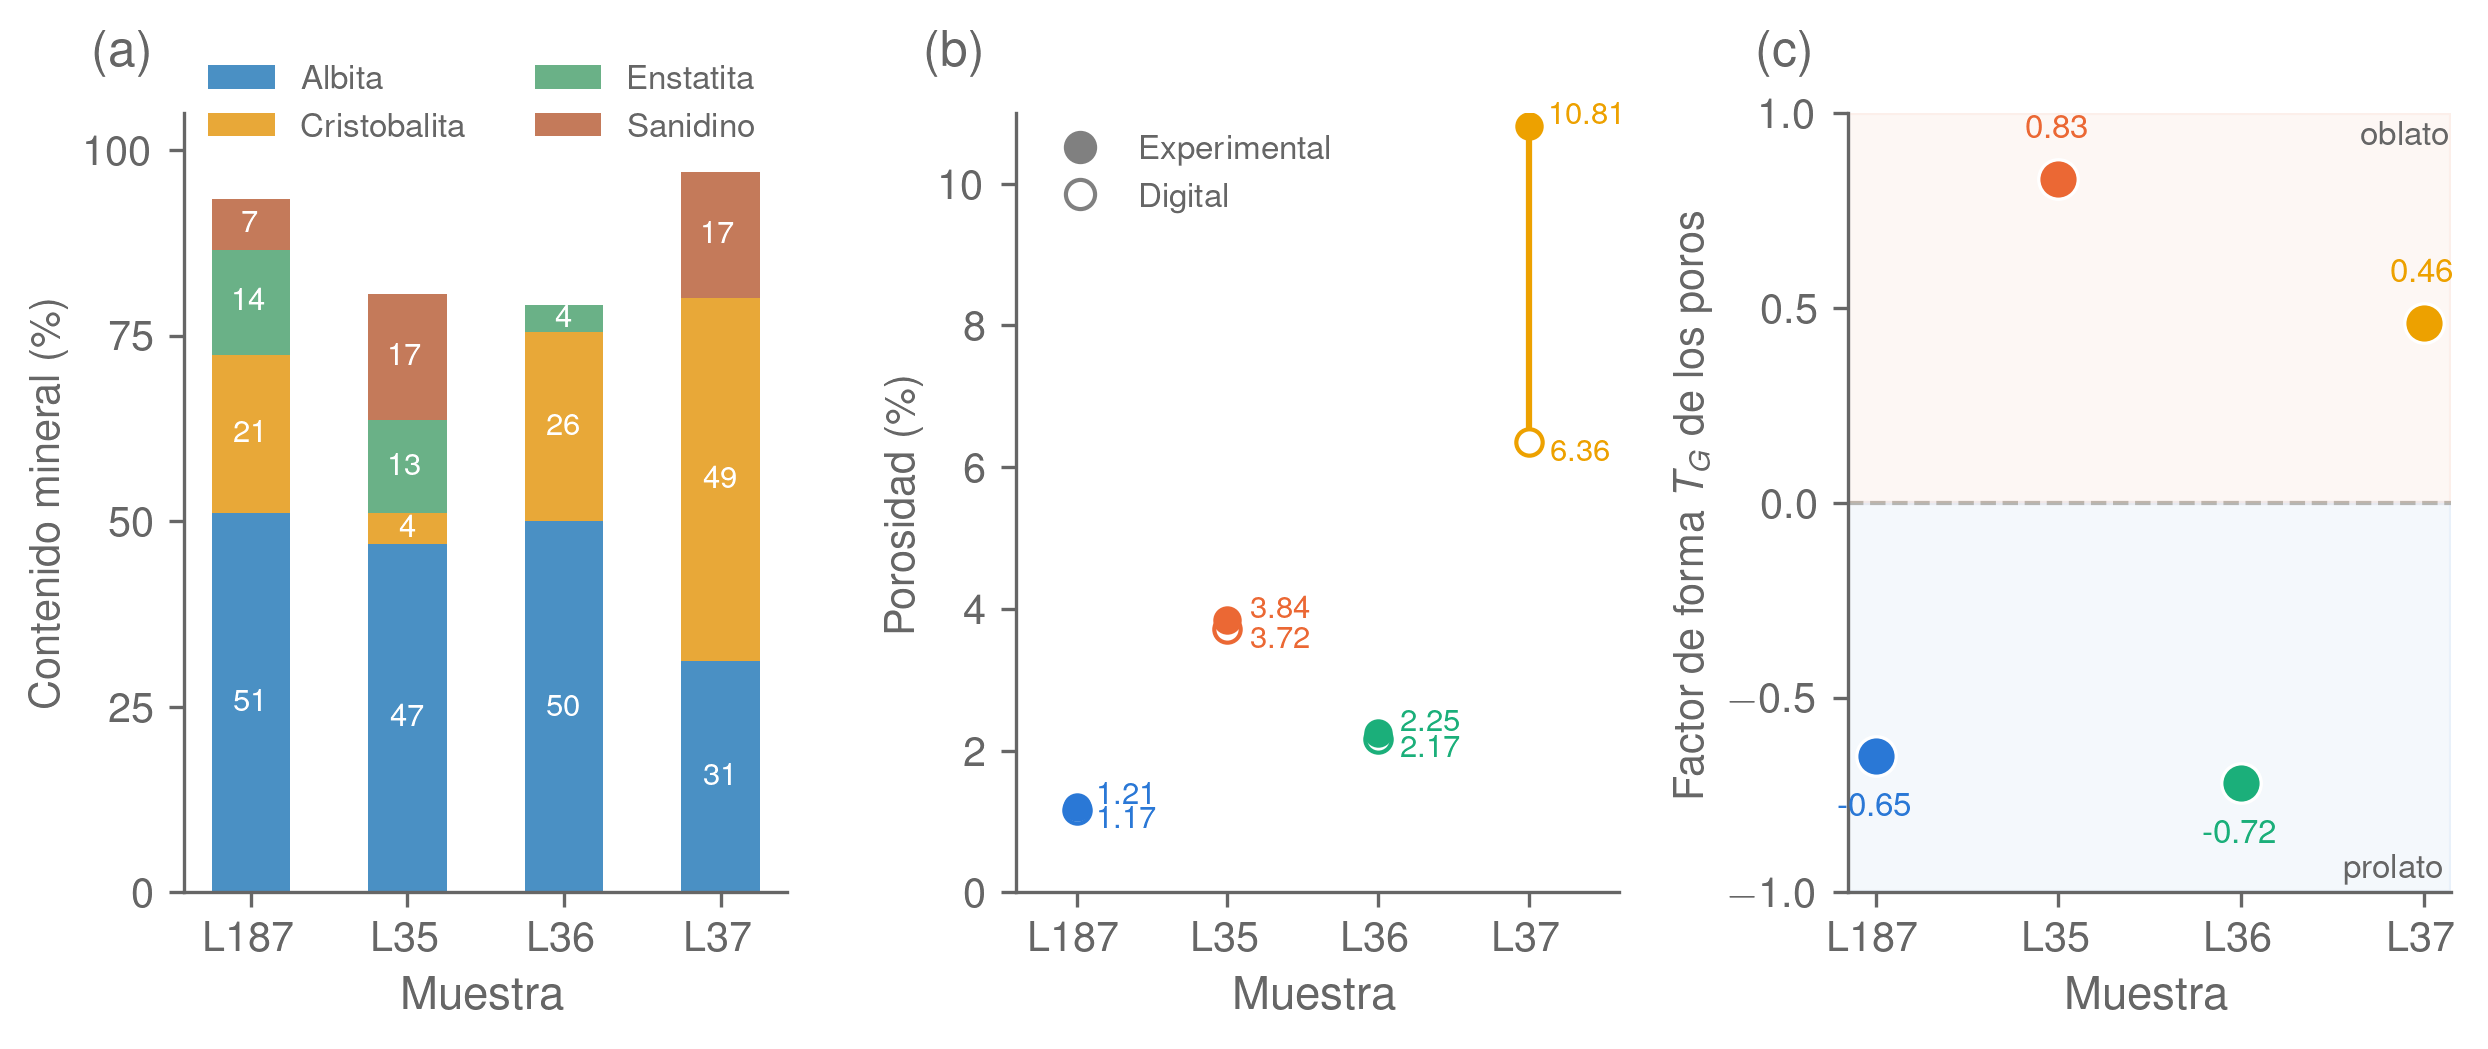

In [40]:
plot_microhetero(df1, save_path='plots/ch5-fig1.png', factor=0.75)

### 5-2

Figura guardada en: plots/ch5-fig2.png


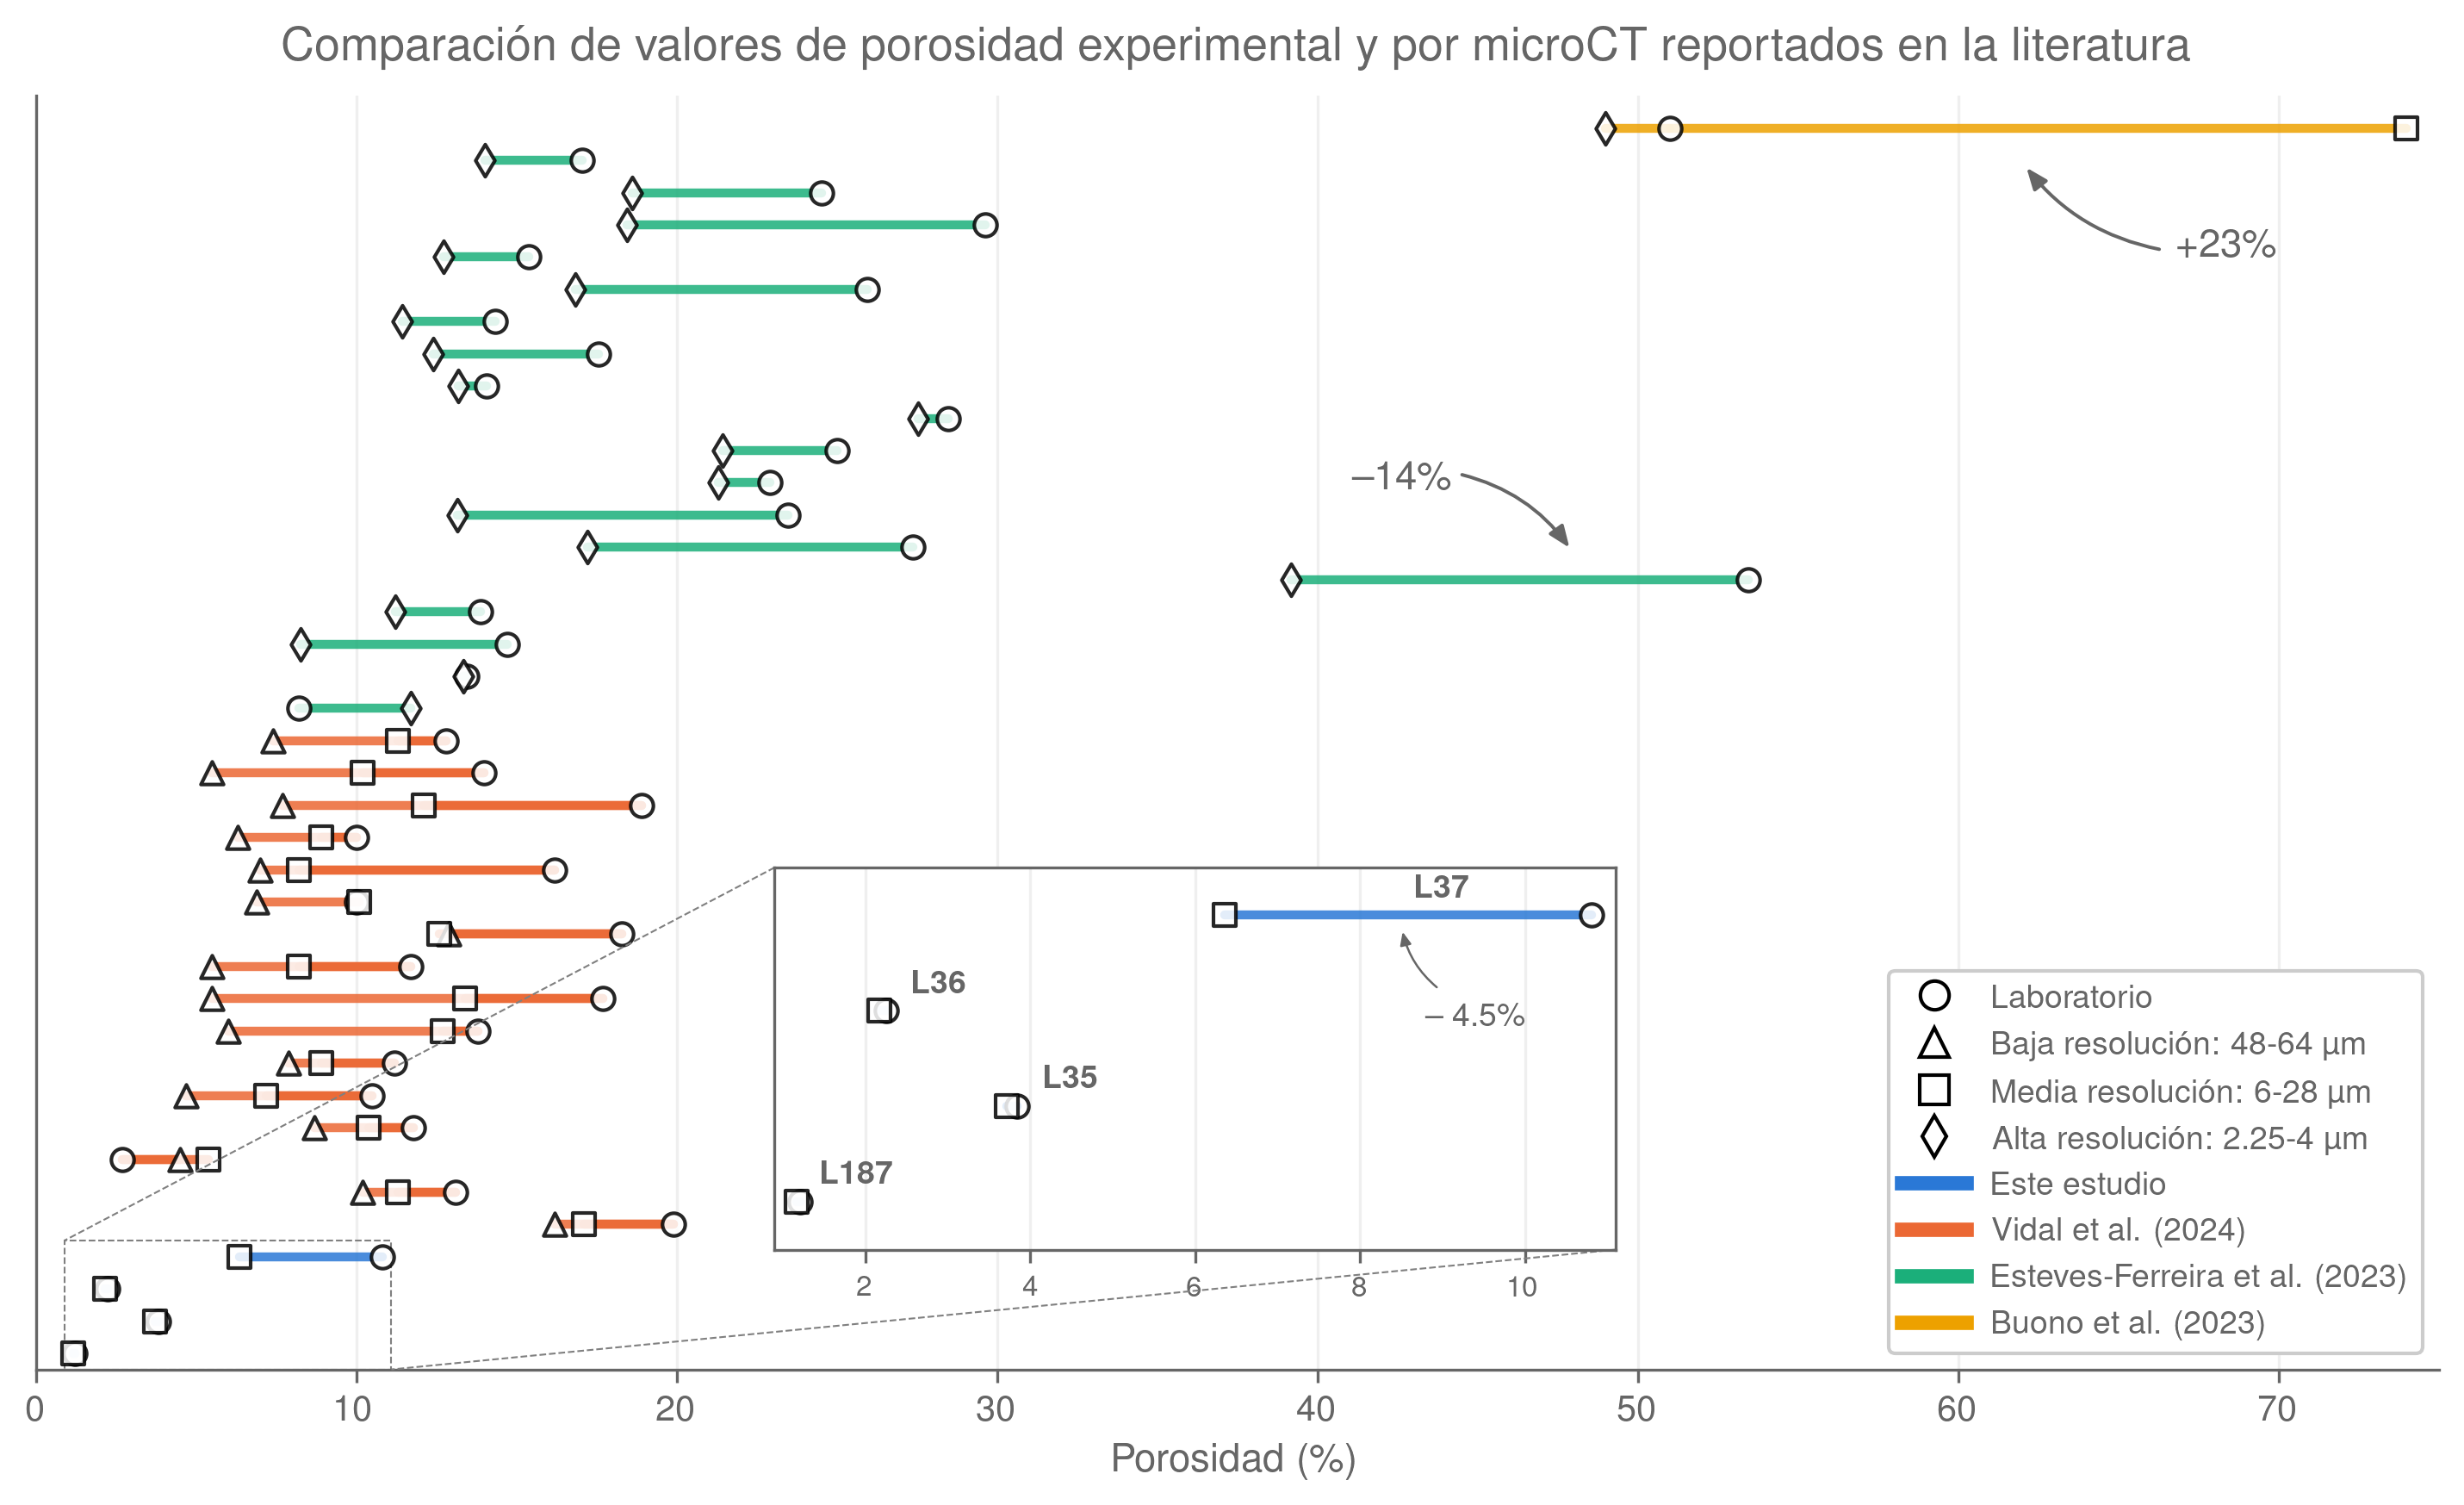

In [41]:
plot_phiDiffs(df2, save_path='plots/ch5-fig2.png', factor=0.8)

### 5-3

Figura guardada en: plots/ch5-fig3.png


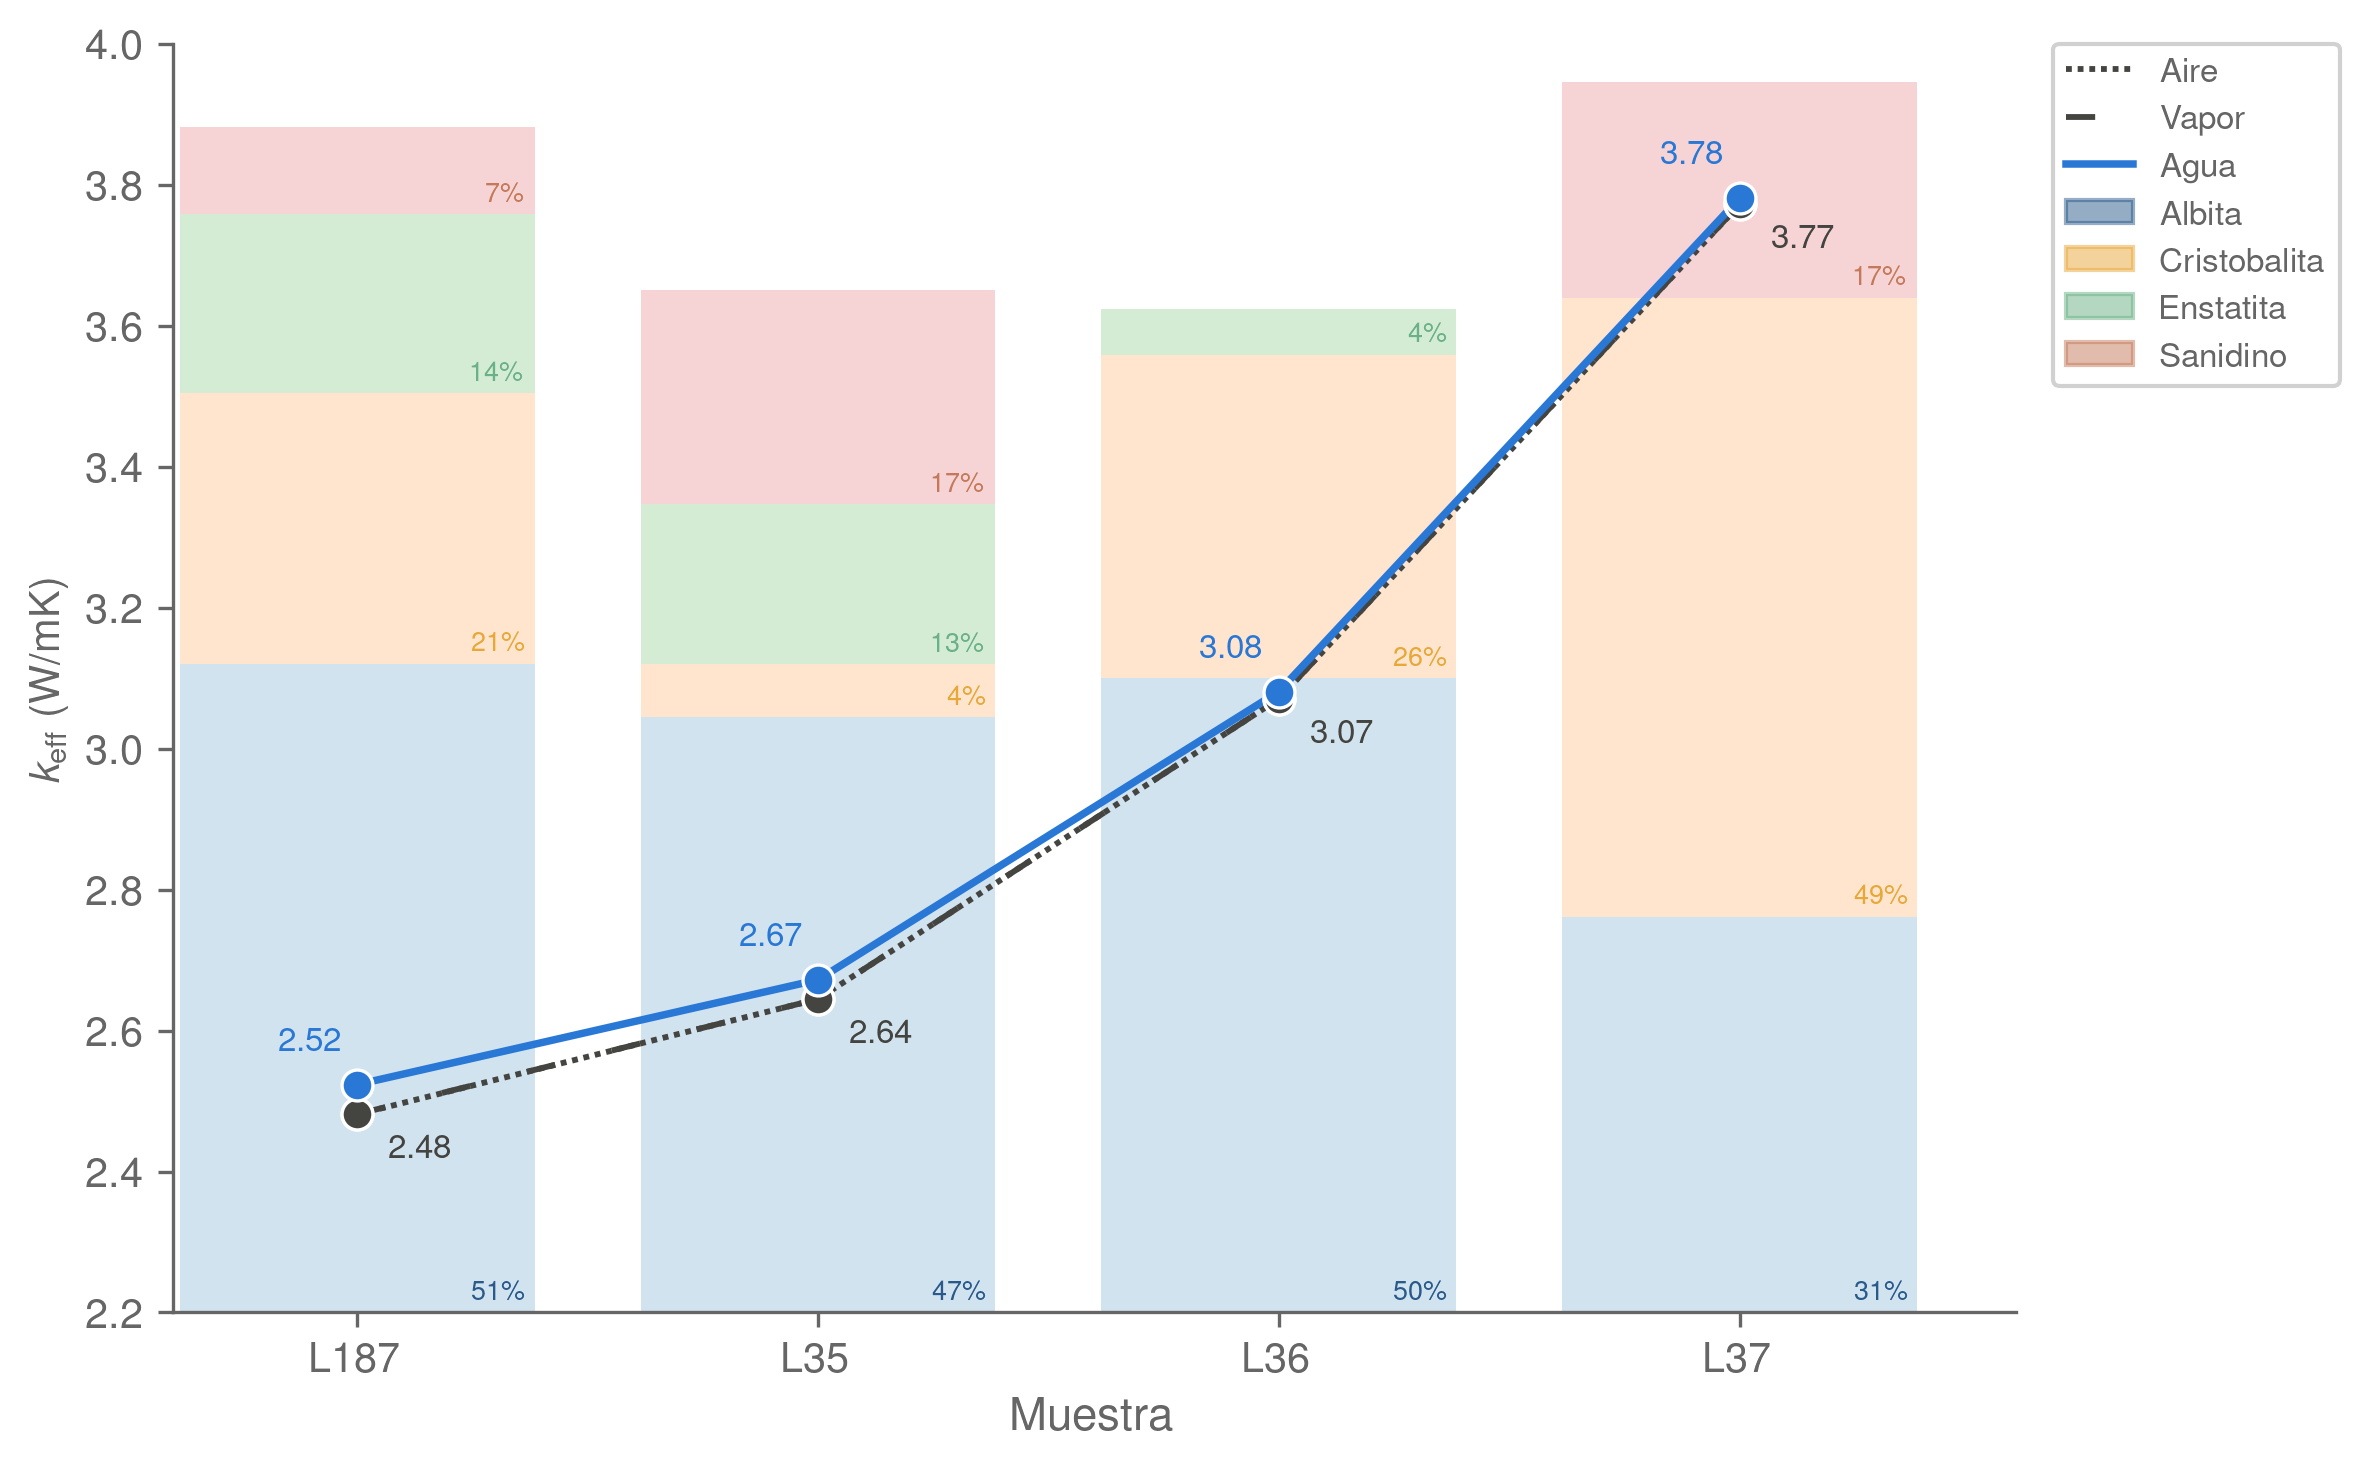

In [42]:
plot_cte_drx(df1, save_path='plots/ch5-fig3.png')

### 5-4

Figura guardada en: plots/ch5-fig4.png


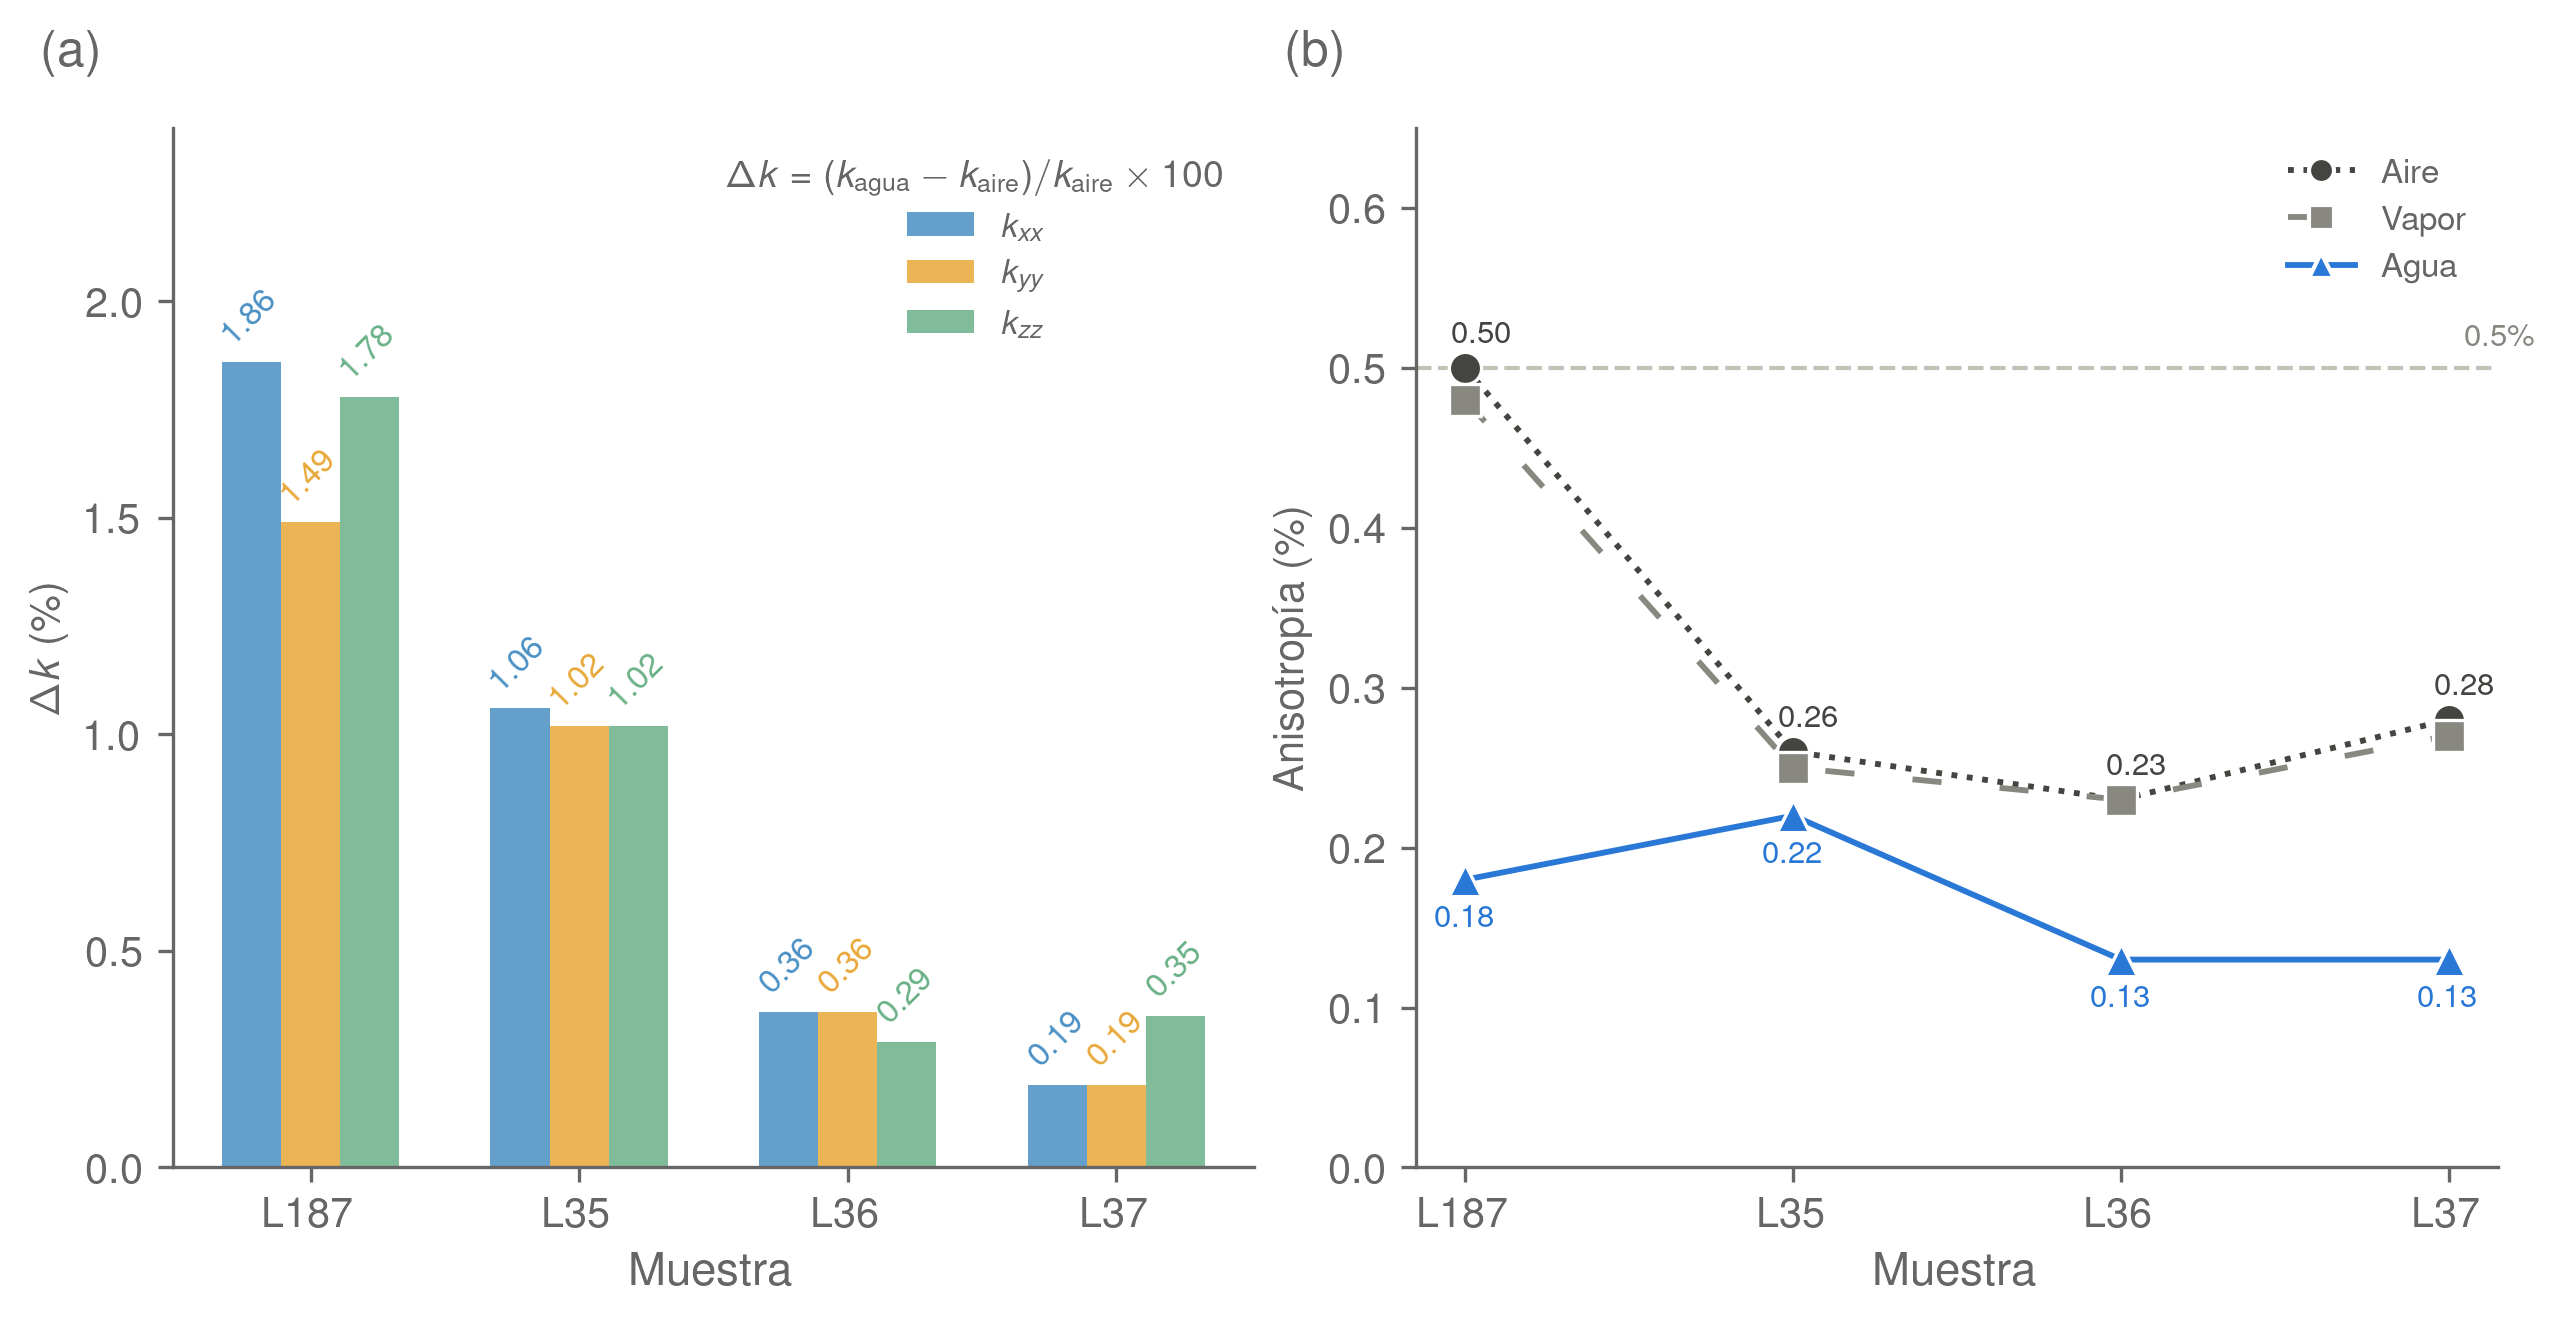

In [43]:
plot_cte_fluid_ani(df1, save_path='plots/ch5-fig4.png')

### 5-5

Figura guardada en: plots/ch5-fig5.png


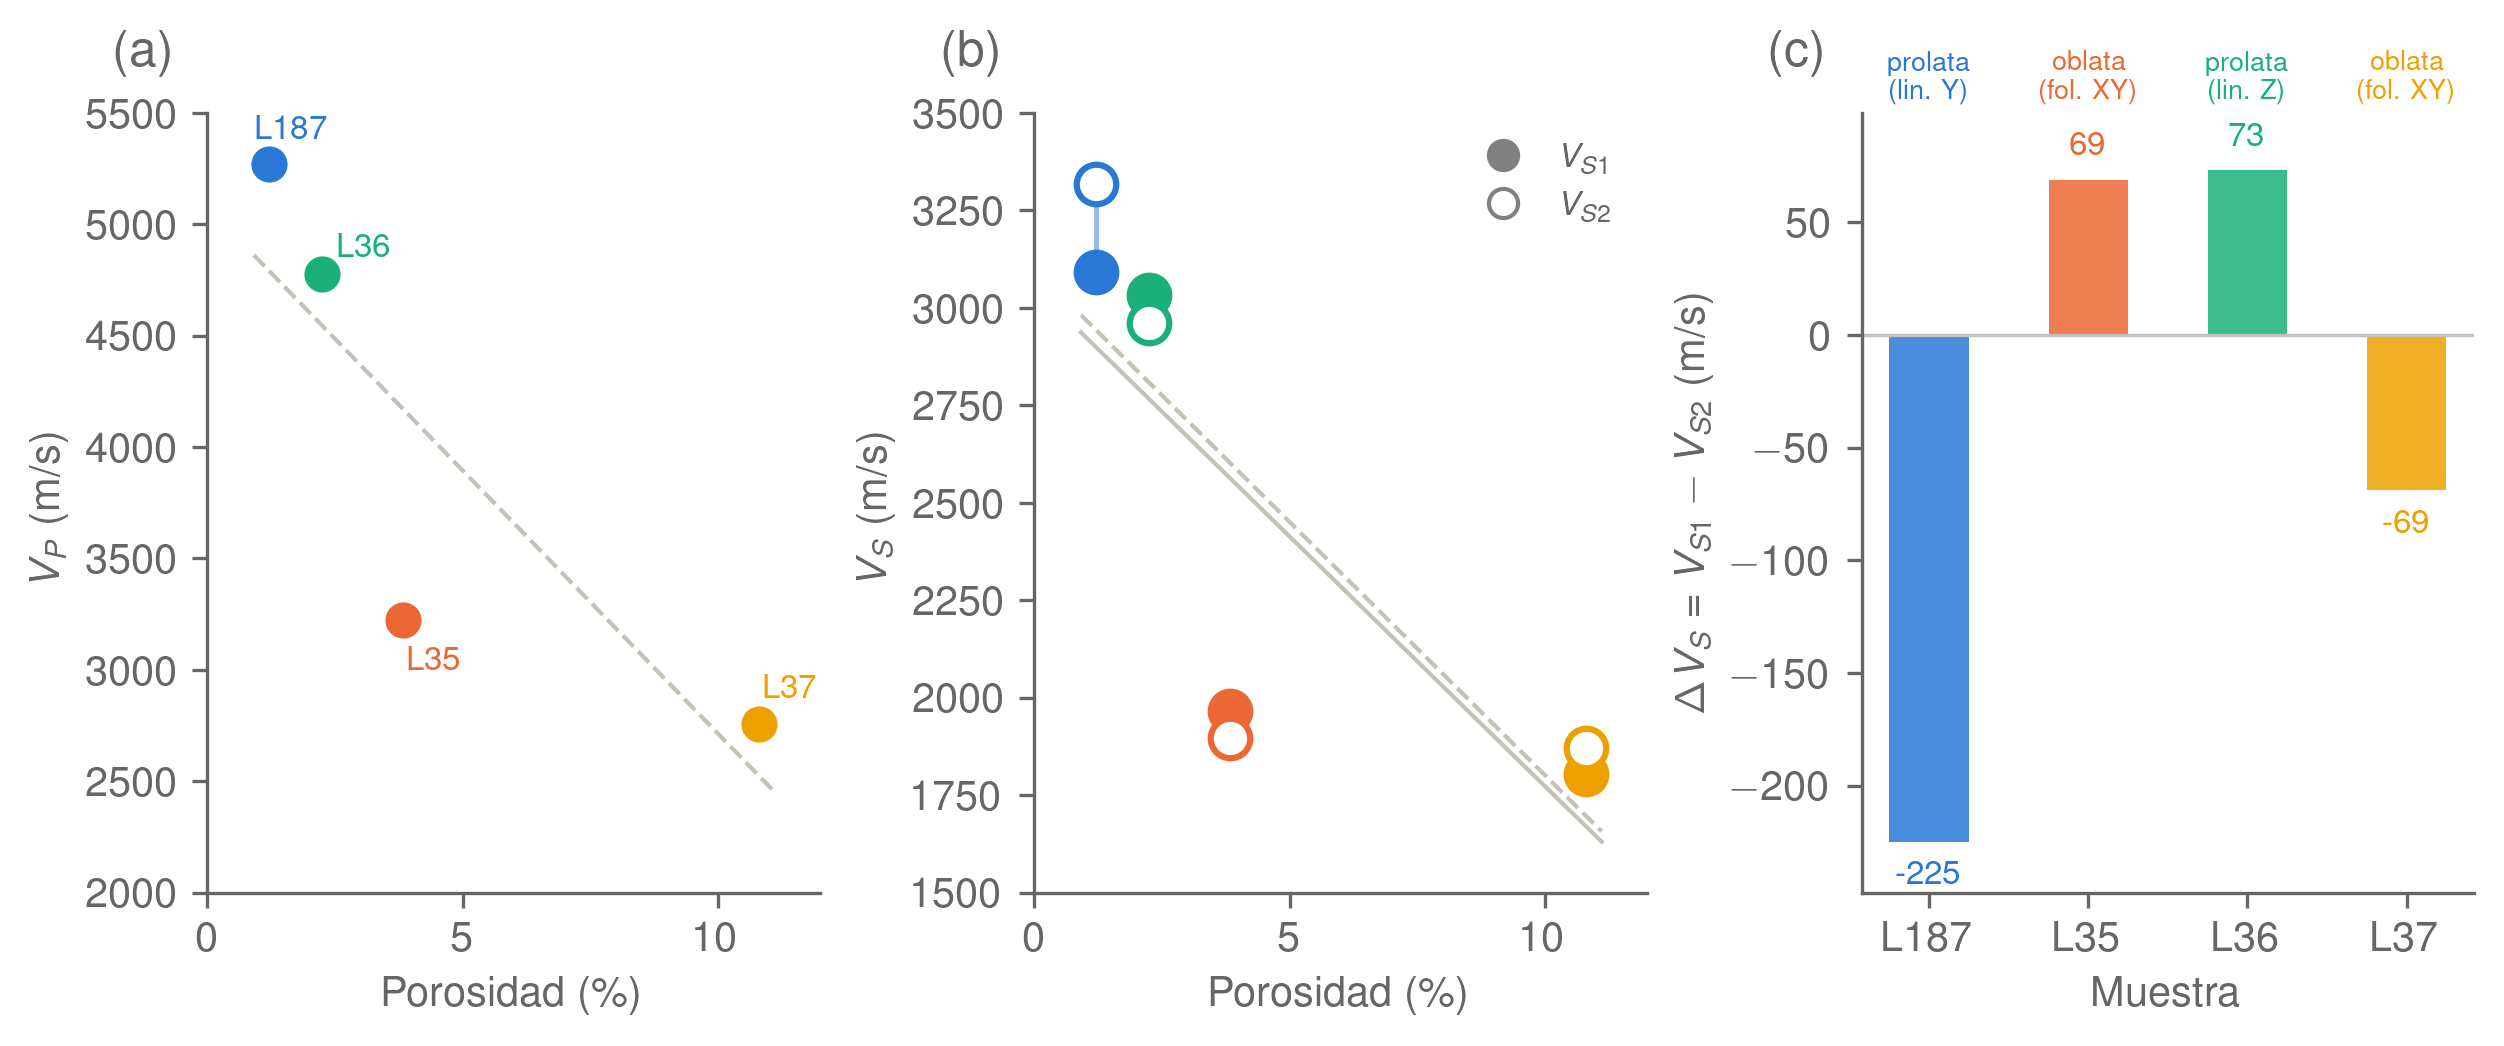

In [44]:
plot_vels(df1, save_path="plots/ch5-fig5.png", factor=0.75)

### 5-6

Figura guardada en: plots/ch5-fig6.png


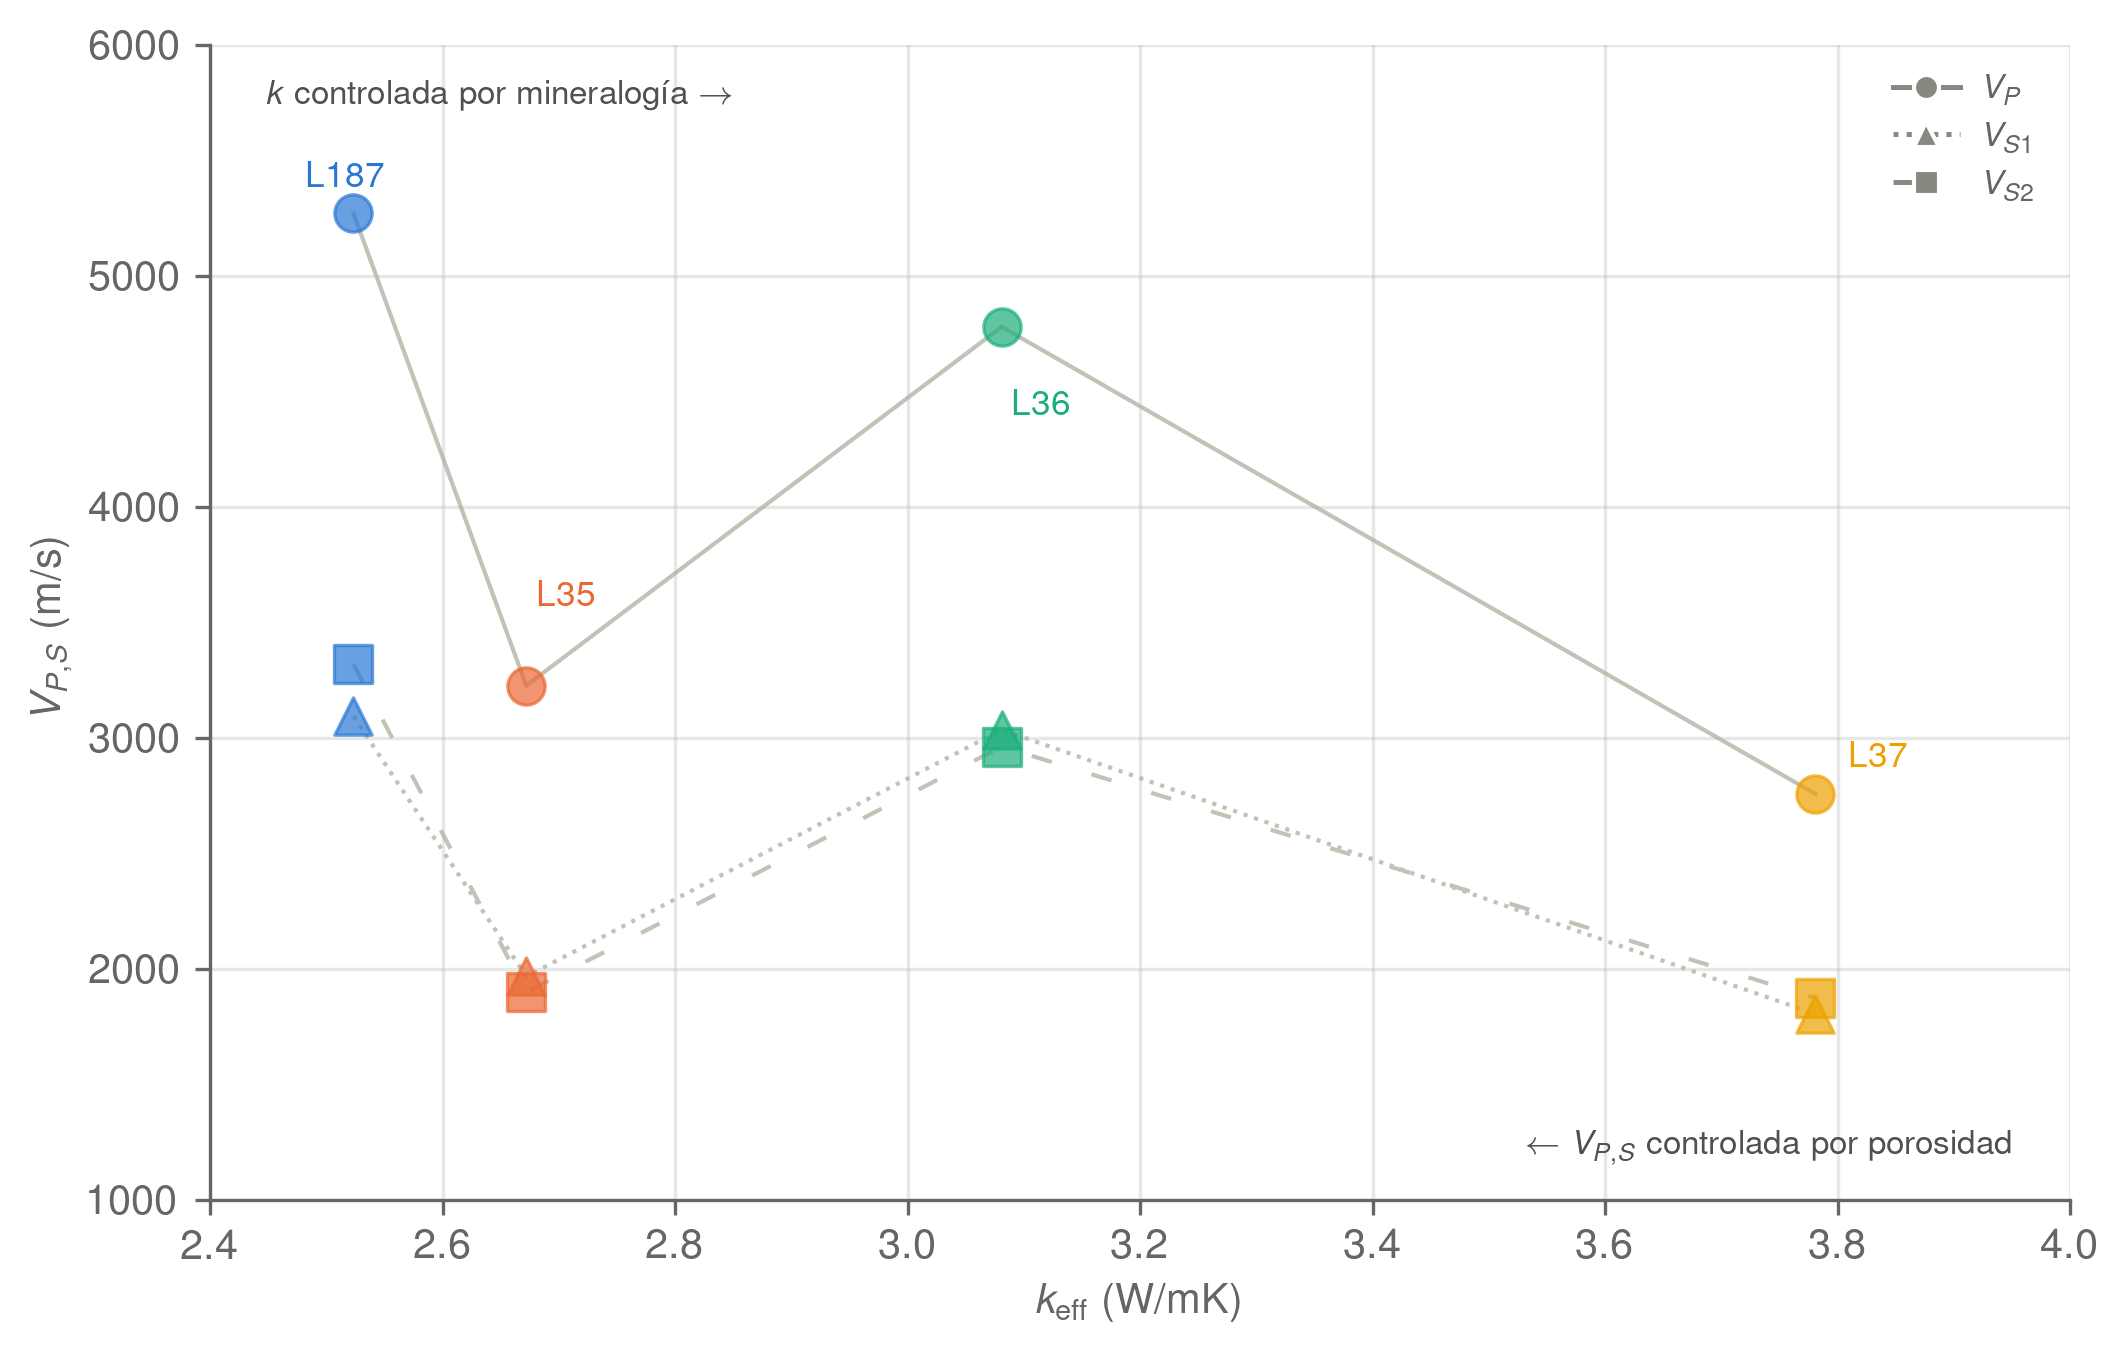

In [45]:
plot_k_vs_v(df1, save_path="plots/ch5-fig6.png")

___